# **<span style="font-family: Arial">Facebook Page Performance - EDA & Data Wrangling </span>**


**Author:** Ozor Moya

**Date:** 08/08/2026

## Project Objective

In this notebook I explore a dataset of 500 Facebook posts from a brand page.  
The goal is to understand what the data looks like before doing any cleaning or modeling.

https://archive.ics.uci.edu/dataset/368/facebook+metrics

- Saving the dataset link for easy access.

---
### 1. Import the necessary libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
### 2. Load Data

In [2]:
df = pd.read_csv("/Users/sa02/class-projects/EOP-Project/P1PortfolioProject/Data/raw_dataset_Facebook.csv", sep=";")

- After loading the csv file, I noticed the dataset uses semicolons (;) to separate columns instead of commas, so I need to tell pandas that with sep=";".

---
### 3. First look at the Data

In [3]:
# Check how many rows and columns of the data
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

# Check how the dataset looks like
df.head()

Rows: 500
Columns: 19


,Page total likes,Type,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0,164
2,139441,Photo,3,12,3,3,0.0,2413,4373,177,113,154,2812,1503,132,0,66.0,14.0,80
3,139441,Photo,2,12,2,10,1.0,50128,87991,2211,790,1119,61027,32048,1386,58,1572.0,147.0,1777
4,139441,Photo,2,12,2,3,0.0,7244,13594,671,410,580,6228,3200,396,19,325.0,49.0,393


- This dataset includes post characteristics, timing information, and engagement metrics.
- The dataset has 500 rows and 19 columns.

---
### 4. Check elements of the data

In [4]:
# Check column names, null values and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page total likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post Month                                                           500 non-null    int64  
 4   Post Weekday                                                         500 non-null    int64  
 5   Post Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7   Lifetime

Column names as stated in the dataset website:

- 1 `Page total likes` - How many people had liked the page when this post was published
- 2 `Type` - Post format: Photo, Status, Link, or Video
- 3  `Category` - Content theme: 1 = Action, 2 = Product, 3 = Inspiration
- 4  `Post Month` - Month published (1 = Jan … 12 = Dec)
- 5  `Post Weekday` - Day of week (1 = Mon … 7 = Sun)
- 6  `Post Hour` - Hour published in 24h format (0–23)
- 7  `Paid` - If the company paid to Facebook for advertising (0 = No, 1 = Yes)
- 8  `Lifetime Post Total Reach` - Unique people who saw this post
- 9  `Lifetime Post Total Impressions` - Total times the post appeared on screen (same person counts multiple times)
- 10  `Lifetime Engaged Users` - Unique people who clicked, liked, commented, or shared
- 11  `Lifetime Post Consumers` - Unique people who clicked anywhere on the post
- 12  `Lifetime Post Consumptions` - Total number of clicks (including repeat clicks)
- 13  `Lifetime Post Impressions by people who have liked your Page` - Impressions seen by existing followers
- 14  `Lifetime Post reach by people who like your Page` - Unique followers who saw the post
- 15  `Lifetime People who have liked your Page and engaged with your post` - Followers who engaged
- 16  `comment` - Number of comments
- 17  `like` - Number of likes
- 18  `share` - Number of shares
- 19  `Total Interactions` - **Target variable** — sum of comment + like + share


- Some columns have extremely long names, will fix these in the following step.
- `Paid`, `like`, `share` are `float64`, should be integers. Probably missing values that forced pandas to use float.
- `Total Interactions` is literally the sum of `comment + like + share`. They cannot be used as model features — that would be giving the model the answer. Will drop them before modeling.

---
### 5. Summary Statistics

In [5]:
# Getting insight
df.describe().round(2)

,Page total likes,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
count,500.00,500.00,500.00,500.00,500.00,499.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,499.00,496.00,500.00
mean,123194.18,1.88,7.04,4.15,7.84,0.28,13903.36,29585.95,920.34,798.77,1415.13,16766.38,6585.49,609.99,7.48,177.95,27.27,212.12
std,16272.81,0.85,3.31,2.03,4.37,0.45,22740.79,76803.25,985.02,882.51,2000.59,59791.02,7682.01,612.73,21.18,323.40,42.61,380.23
min,81370.00,1.00,1.00,1.00,1.00,0.00,238.00,570.00,9.00,9.00,9.00,567.00,236.00,9.00,0.00,0.00,0.00,0.00
25%,112676.00,1.00,4.00,2.00,3.00,0.00,3315.00,5694.75,393.75,332.50,509.25,3969.75,2181.50,291.00,1.00,56.50,10.00,71.00
50%,129600.00,2.00,7.00,4.00,9.00,0.00,5281.00,9051.00,625.50,551.50,851.00,6255.50,3417.00,412.00,3.00,101.00,19.00,123.50
75%,136393.00,3.00,10.00,6.00,11.00,1.00,13168.00,22085.50,1062.00,955.50,1463.00,14860.50,7989.00,656.25,7.00,187.50,32.25,228.50
max,139441.00,3.00,12.00,7.00,23.00,1.00,180480.00,1110282.00,11452.00,11328.00,19779.00,1107833.00,51456.00,4376.00,372.00,5172.00,790.00,6334.00


- Here I rounded the dataset into two decimal places by using round method for easy readability.

---
### 6. Fixing column names for ease of readability

In [6]:
#Using snake_case method
df.columns = [ 
    'page_likes',
    'post_type',
    'category',
    'post_month',
    'post_weekday',
    'post_hour',
    'paid',
    'total_reach',
    'total_impressions',
    'engaged_users',
    'post_consumers',
    'post_consumptions',
    'fan_impressions',
    'fan_reach',
    'fan_engaged',
    'comments',
    'likes',
    'shares',
    'total_interactions'
]
# Verify the rename worked correctly
df.head(2)

,page_likes,post_type,category,post_month,post_weekday,post_hour,paid,total_reach,total_impressions,engaged_users,post_consumers,post_consumptions,fan_impressions,fan_reach,fan_engaged,comments,likes,shares,total_interactions
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0,164


---
### 7. Checking columns with missing values and duplicates

In [8]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(1)

missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
print(missing_df[missing_df['Count'] > 0])

        Count  Percent
paid        1      0.2
likes       1      0.2
shares      4      0.8


- Showing only columns that has actuall missing values for a cleaner look.
- Missing values are <1%. Will impute the values instead of dropping them.

In [12]:
# Check for duplicates
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')

Duplicate rows: 0


- No duplicated rows, good to proceed.

---
### 8. Fixing Datatype issue and filling missing values

In [9]:
df['paid']   = df['paid'].fillna(0).astype(int)
df['likes']  = df['likes'].fillna(df['likes'].median()).astype(int)
df['shares'] = df['shares'].fillna(df['shares'].median()).astype(int)

- likes and shares got median imputation because median is unaffected by extreme outliers in this data.
- Since we know paid, like and share doesnt need to be in decimal form. I changed the datatype to integer.

In [20]:
# Check again to see if all columns are filled
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   page_likes          500 non-null    int64 
 1   post_type           500 non-null    object
 2   category            500 non-null    int64 
 3   post_month          500 non-null    int64 
 4   post_weekday        500 non-null    int64 
 5   post_hour           500 non-null    int64 
 6   paid                500 non-null    int64 
 7   total_reach         500 non-null    int64 
 8   total_impressions   500 non-null    int64 
 9   engaged_users       500 non-null    int64 
 10  post_consumers      500 non-null    int64 
 11  post_consumptions   500 non-null    int64 
 12  fan_impressions     500 non-null    int64 
 13  fan_reach           500 non-null    int64 
 14  fan_engaged         500 non-null    int64 
 15  comments            500 non-null    int64 
 16  likes               500 no

---
### 9. Explore Categorical Features

In [15]:
# What types of posts are there?
print('Post type breakdown:')
print(df['post_type'].value_counts())
print()
print('Paid vs Organic breakdown:')
print(df['paid'].value_counts())
print()
print('Category breakdown:')
print(df['category'].value_counts().sort_index())

Post type breakdown:
post_type
Photo     426
Status     45
Link       22
Video       7
Name: count, dtype: int64

Paid vs Organic breakdown:
paid
0    361
1    139
Name: count, dtype: int64

Category breakdown:
category
1    215
2    130
3    155
Name: count, dtype: int64


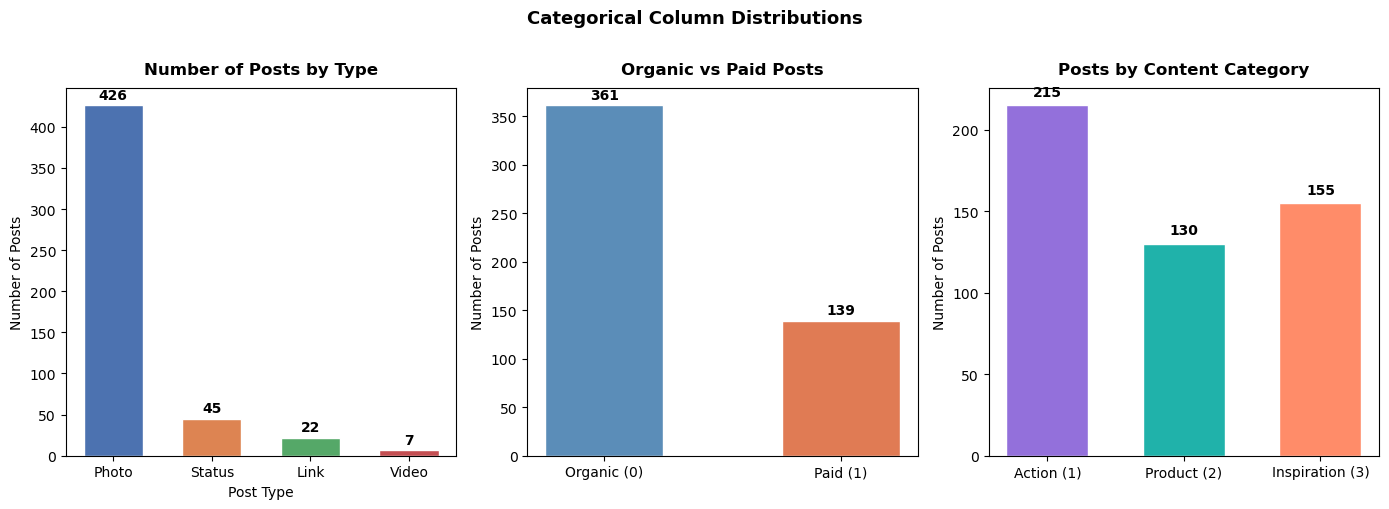

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Post type bar chart
type_counts = df['post_type'].value_counts()
bars = axes[0].bar(type_counts.index, type_counts.values,
                   color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='white', width=0.6)
axes[0].set_title('Number of Posts by Type', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Post Type')
axes[0].set_ylabel('Number of Posts')
# Add count labels on top of each bar
for bar, val in zip(bars, type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                 str(val), ha='center', va='bottom', fontweight='bold')

# Paid vs organic
paid_counts = df['paid'].value_counts().sort_index()
bars2 = axes[1].bar(['Organic (0)', 'Paid (1)'], paid_counts.values,
                    color=['#5B8DB8','#E07B54'], edgecolor='white', width=0.5)
axes[1].set_title('Organic vs Paid Posts', fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('Number of Posts')
for bar, val in zip(bars2, paid_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                 str(val), ha='center', va='bottom', fontweight='bold')

# Category breakdown
cat_counts = df['category'].value_counts().sort_index()
bars3 = axes[2].bar(['Action (1)', 'Product (2)', 'Inspiration (3)'], cat_counts.values,
                    color=['#9370DB','#20B2AA','#FF8C69'], edgecolor='white', width=0.6)
axes[2].set_title('Posts by Content Category', fontsize=12, fontweight='bold', pad=10)
axes[2].set_ylabel('Number of Posts')
for bar, val in zip(bars3, cat_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                 str(val), ha='center', va='bottom', fontweight='bold')

plt.suptitle('Categorical Column Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../docs/fig_01_categorical_distributions.png', dpi=120, bbox_inches='tight')

- **Post type is very unbalanced.** Photos dominate with 426 posts. Videos are barely represented with only 7 posts. This means any conclusions draw about Video performance might not be reliable — it's a tiny sample.
- **Most posts are organic.** 360 posts had no paid promotion. 139 were advertised in Facebook.
- **Category 1 (Action) is most common** with 215 posts, followed by Category 3 (Inspiration) with 155, then Category 2 (Product) with 130.

---
### 10. Explore Numeric Features

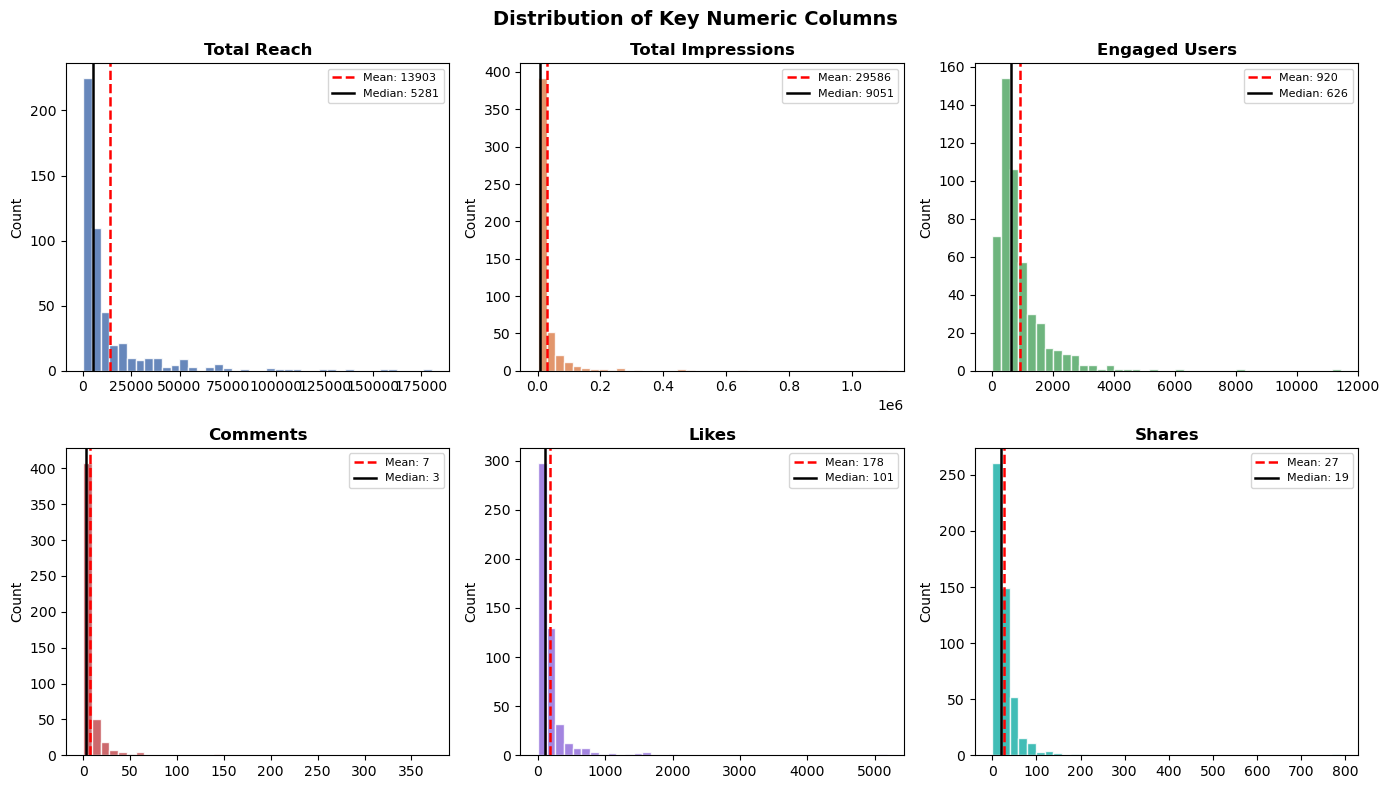

In [32]:
# The key engagement/reach metrics I want to visualise
features = ['total_reach', 'total_impressions', 'engaged_users', 'comments', 'likes', 'shares']
colors    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#9370DB', '#20B2AA']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(features, colors)):
    axes[i].hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    # Add mean and median lines
    axes[i].axvline(df[col].mean(),   color='red',   linestyle='--', lw=1.8,
                    label=f'Mean: {df[col].mean():.0f}')
    axes[i].axvline(df[col].median(), color='black', linestyle='-',  lw=1.8,
                    label=f'Median: {df[col].median():.0f}')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

fig.suptitle('Distribution of Key Numeric Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/fig_02_numeric_distributions.png', dpi=120, bbox_inches='tight')

- Every performance metric is **right-skewed** — all distributions have a long right tail. The red mean line is always to the right of the black median line, which is the visual signature of skew.
- I will use a log transformation to fix it and apply it to `total_interactions` in the next section.

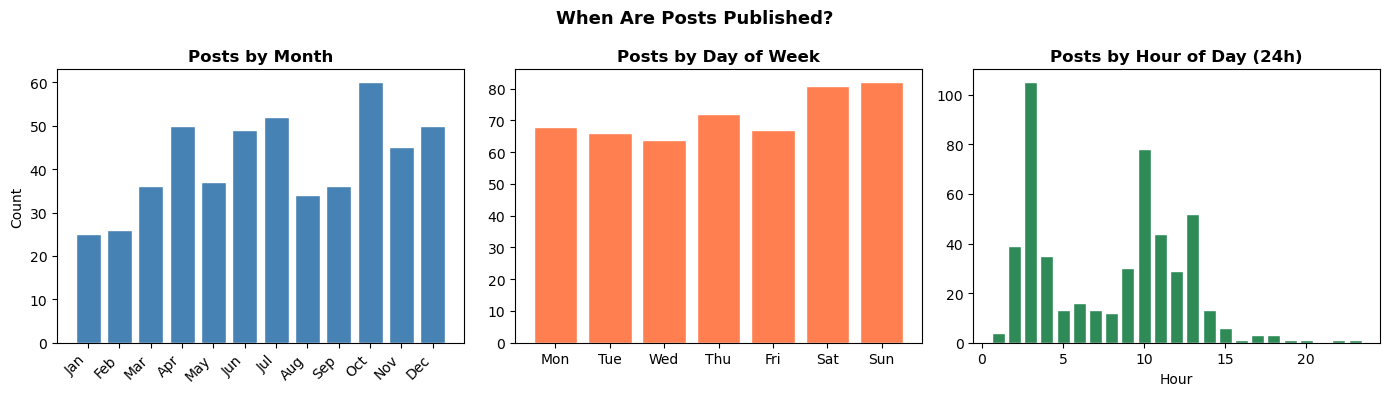

In [18]:
# Also look at the timing patterns
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

month_labels   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
weekday_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

month_counts   = df['post_month'].value_counts().reindex(range(1, 13), fill_value=0)
weekday_counts = df['post_weekday'].value_counts().reindex(range(1, 8), fill_value=0)
hour_counts    = df['post_hour'].value_counts().sort_index()

# By Month
axes[0].bar(range(1,13), month_counts.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(month_labels, rotation=45, ha='right')
axes[0].set_title('Posts by Month', fontweight='bold')
axes[0].set_ylabel('Count')

# By Week
axes[1].bar(range(1,8), weekday_counts.values, color='coral', edgecolor='white')
axes[1].set_xticks(range(1,8))
axes[1].set_xticklabels(weekday_labels)
axes[1].set_title('Posts by Day of Week', fontweight='bold')

# By Hour
axes[2].bar(hour_counts.index, hour_counts.values, color='seagreen', edgecolor='white')
axes[2].set_title('Posts by Hour of Day (24h)', fontweight='bold')
axes[2].set_xlabel('Hour')

fig.suptitle('When Are Posts Published?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/fig_03_posting_timing.png', dpi=120, bbox_inches='tight')

- More posts in the second half of the year (July–December). Probably because theres a lot of holidays beginning July to December.
- Tuesday and Thursday are the most popular posting days — weekends are quieter.
- Most posts go out between hours 3–12 (early morning through midday). Very few after 8pm.

---
### 11. Target Variable Analysis

In [22]:
print('total_interactions — key stats:')
print(f'  Mean:     {df.total_interactions.mean():.1f}')
print(f'  Median:   {df.total_interactions.median():.1f}')
print(f'  Std Dev:  {df.total_interactions.std():.1f}')
print(f'  Min:      {df.total_interactions.min()}')
print(f'  Max:      {df.total_interactions.max()}')
print(f'  Skewness: {df.total_interactions.skew():.2f}')

total_interactions — key stats:
  Mean:     212.1
  Median:   123.5
  Std Dev:  380.2
  Min:      0
  Max:      6334
  Skewness: 9.71


Skew (raw):  9.71
Skew (log):  -1.01


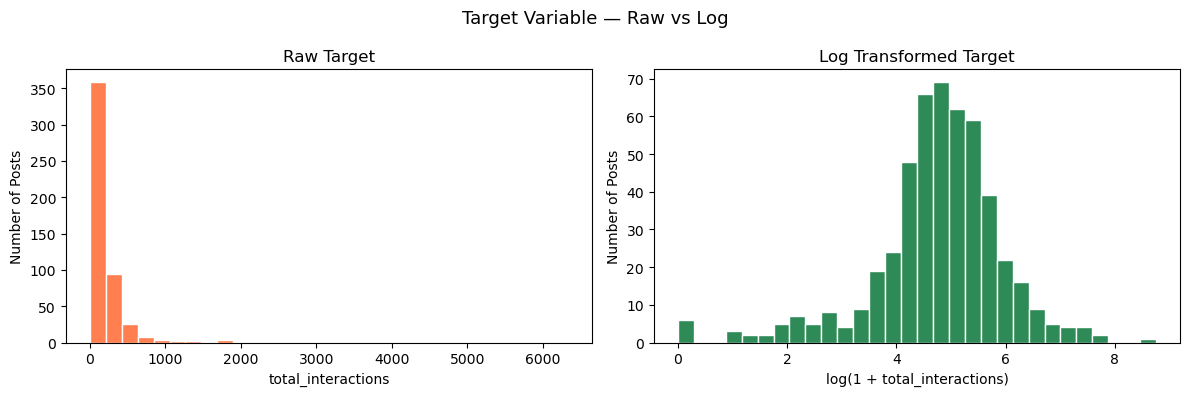

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw
axes[0].hist(df['total_interactions'], bins=30, color='coral', edgecolor='white')
axes[0].set_title('Raw Target')
axes[0].set_xlabel('total_interactions')
axes[0].set_ylabel('Number of Posts')

# Log
axes[1].hist(np.log1p(df['total_interactions']), bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Log Transformed Target')
axes[1].set_xlabel('log(1 + total_interactions)')
axes[1].set_ylabel('Number of Posts')

plt.suptitle('Target Variable — Raw vs Log', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/fig_04_target_variable.png', dpi=120, bbox_inches='tight')

print(f"Skew (raw):  {df['total_interactions'].skew():.2f}")
print(f"Skew (log):  {np.log1p(df['total_interactions']).skew():.2f}")

- The raw distribution is extremely skewed, after performing log transformation, the distribution looks like normally distributed (bell-shaped)

---
### 12. Outlier Detection with Boxplots

In [39]:
# Check outliers per column using the IQR method
print('Outlier count per column (IQR method):')

outlier_summary = {}
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers  = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_summary[col] = n_outliers
    pct = n_outliers / len(df) * 100
    print(f'  {col:35} : {n_outliers:3} outliers ({pct:.1f}%)')

Outlier count per column (IQR method):
  page_likes                          :   0 outliers (0.0%)
  category                            :   0 outliers (0.0%)
  post_month                          :   0 outliers (0.0%)
  post_weekday                        :   0 outliers (0.0%)
  post_hour                           :   0 outliers (0.0%)
  paid                                :   0 outliers (0.0%)
  total_reach                         :  69 outliers (13.8%)
  total_impressions                   :  68 outliers (13.6%)
  engaged_users                       :  44 outliers (8.8%)
  post_consumers                      :  38 outliers (7.6%)
  post_consumptions                   :  49 outliers (9.8%)
  fan_impressions                     :  53 outliers (10.6%)
  fan_reach                           :  45 outliers (9.0%)
  fan_engaged                         :  59 outliers (11.8%)
  comments                            :  52 outliers (10.4%)
  likes                               :  40 outliers (8.

- Here, the performance metric columns have quite a few outliers — `total_reach` has 69 (14%), `total_impressions` has 68 (14%). This makes sense given the skewed distributions we saw in the histograms. A few posts went viral and their numbers are way above what a normal post gets.

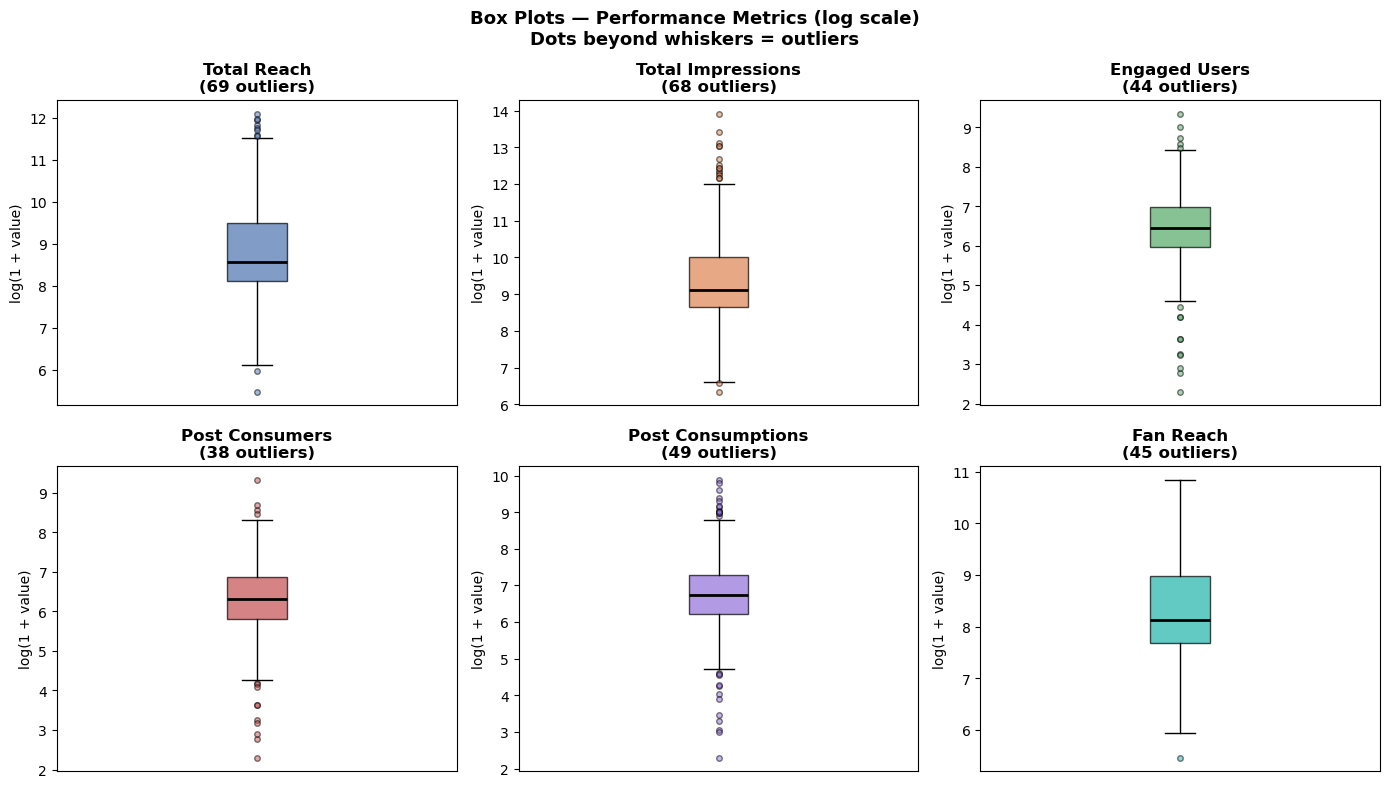

In [40]:
# Box plots for the main performance metrics
# I'll use log scale because the outliers are so extreme they flatten the box otherwise
perf_cols = ['total_reach', 'total_impressions', 'engaged_users',
                    'post_consumers', 'post_consumptions', 'fan_reach']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

box_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#9370DB', '#20B2AA']

for i, (col, color) in enumerate(zip(perf_cols, box_colors)):
    # Use log scale to make the box visible — otherwise extreme outliers squash the box
    log_vals = np.log1p(df[col])
    bp = axes[i].boxplot(log_vals, patch_artist=True, vert=True,
        boxprops=dict(facecolor=color, alpha=0.7),
        medianprops=dict(color='black', lw=2),
        flierprops=dict(marker='o', markerfacecolor=color,
             markersize=4, alpha=0.5))

    # Calculate outlier count for annotation
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]

    axes[i].set_title(f'{col.replace("_"," ").title()}\n({n_out} outliers)', fontweight='bold')
    axes[i].set_ylabel('log(1 + value)')
    axes[i].set_xticks([])

fig.suptitle('Box Plots — Performance Metrics (log scale)\nDots beyond whiskers = outliers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/fig_05_boxplots_performance.png', dpi=120, bbox_inches='tight')
plt.show()

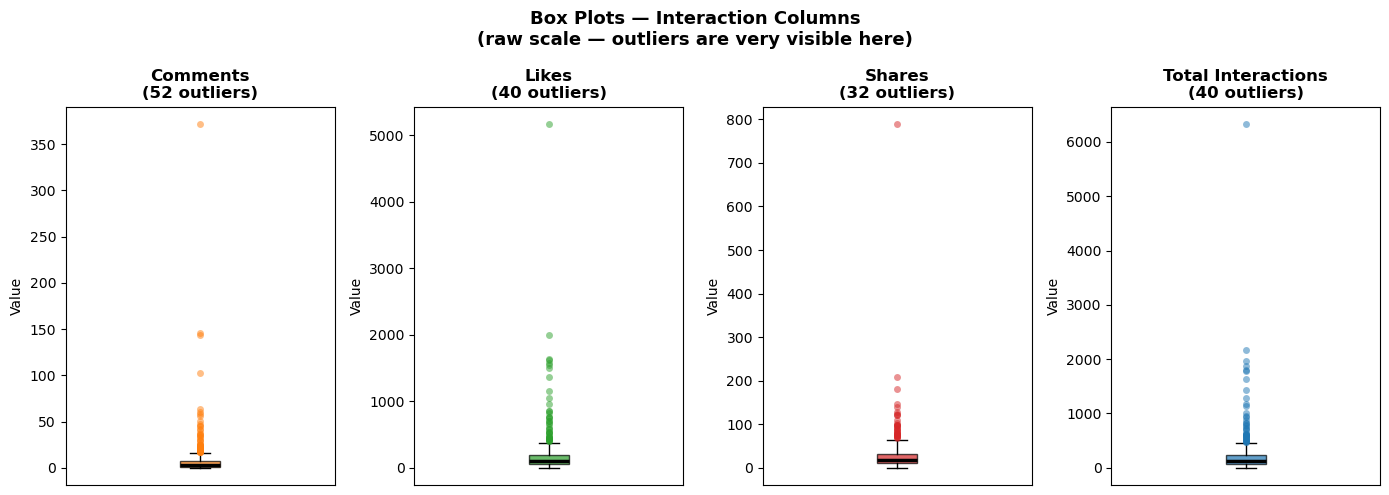

In [37]:
# Box plots for interaction columns and the target variable
interaction_cols = ['comments', 'likes', 'shares', 'total_interactions']
int_colors       = ['#FF7F0E', '#2CA02C', '#D62728', '#1F77B4']

fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for i, (col, color) in enumerate(zip(interaction_cols, int_colors)):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', lw=2.5),
                    flierprops=dict(marker='o', markerfacecolor=color,
                                    markersize=5, alpha=0.5, markeredgewidth=0))

    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]

    axes[i].set_title(f'{col.replace("_"," ").title()}\n({n_out} outliers)', fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

fig.suptitle('Box Plots — Interaction Columns\n(raw scale — outliers are very visible here)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/fig_06_boxplots_interactions.png', dpi=120, bbox_inches='tight')
plt.show()

/var/folders/0h/m0pj4vt94rv015djnpf57pv00000gn/T/ipykernel_19551/3729232013.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_type, labels=post_types, patch_artist=True,


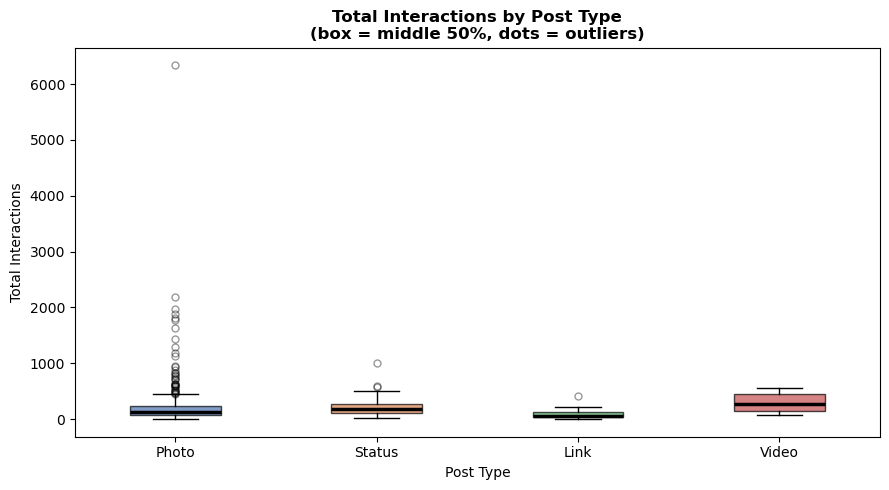

Median total_interactions by post type:
post_type
Video     271.0
Status    186.0
Photo     122.0
Link       52.5
Name: total_interactions, dtype: float64


In [38]:
# Compare interactions across post types — grouped box plot
fig, ax = plt.subplots(figsize=(9, 5))

# Collect data by post type for side-by-side boxplots
post_types = df['post_type'].unique()
data_by_type = [df[df['post_type'] == t]['total_interactions'].values for t in post_types]

bp = ax.boxplot(data_by_type, labels=post_types, patch_artist=True,
                medianprops=dict(color='black', lw=2.5),
                flierprops=dict(marker='o', markersize=5, alpha=0.4))

colors_list = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Total Interactions by Post Type\n(box = middle 50%, dots = outliers)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Post Type')
ax.set_ylabel('Total Interactions')

plt.tight_layout()
plt.savefig('../docs/fig_07_boxplot_by_type.png', dpi=120, bbox_inches='tight')
plt.show()

# Print median per type for reference
print('Median total_interactions by post type:')
print(df.groupby('post_type')['total_interactions'].median().sort_values(ascending=False))

- **The performance metric columns (`total_reach`, `total_impressions`) have the most outliers** — about 14% each. This confirms there are viral posts with reach far above the typical range.

- **`total_interactions` has 40 outliers (8%).** In the box plot you can see the box (where most posts sit) is quite low, but there are many dots stretching way up — those are the viral posts.

- **`comments` has the most extreme skew** (skewness = 11.77). A few posts triggered intense discussion while most get just a few comments.

- **Status posts have the highest median interactions** despite being the second-least common type. Photos have a much wider spread.
- I'm keeping the outliers. Since these viral posts are real — they happened. Removing them would mean training a model that doesn't account for high-performing posts at all. Instead, I'll use a log transformation on the target variable which naturally reduces the impact of extreme values.

---
### 13. Correlation Heatmap

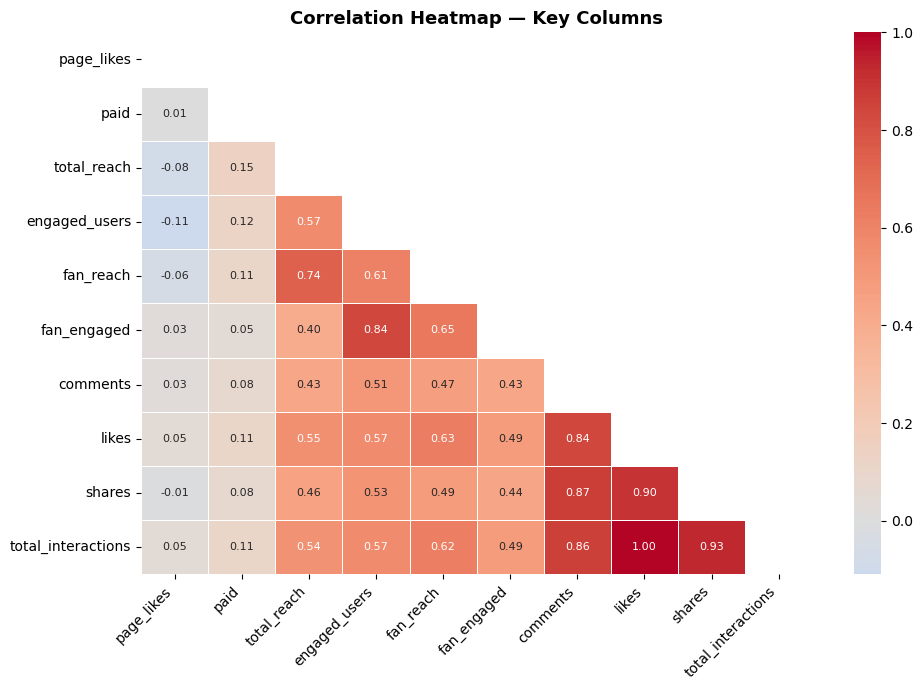

In [41]:
# Correlation heatmap
num_cols_for_heatmap = [
    'page_likes', 'paid', 'total_reach', 'engaged_users',
    'fan_reach', 'fan_engaged', 'comments', 'likes', 'shares', 'total_interactions'
]

plt.figure(figsize=(10, 7))
corr_matrix = df[num_cols_for_heatmap].corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Only show lower triangle

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Key Columns', fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../docs/fig_08_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

- likes & total_interactions (1.00) — because total_interactions literally includes likes
- shares & total_interactions (0.93) — Nearly perfect, same reason
- shares & likes (0.90) — People who like posts also tend to share them
- total_reach & fan_reach (0.74) — When a post reaches more people overall, it naturally reaches more fans too
- engaged_users & fan_engaged (0.84) — Fans make up most of the people who actually engage
- total_reach & total_interactions (0.54) — This is key! More reach = more interactions. Reach drives engagement
- page_likes & total_interactions  (0.05) — Having more page followers barely affects how individual posts perform!
- paid & total_interactions (0.11) — Paying to boost a post only slightly increases interactions
- page_likes & total_reach (-0.08) — Slightly negative, meaning bigger pages don't automatically get more reach per post


---
### 14. Scatter plot

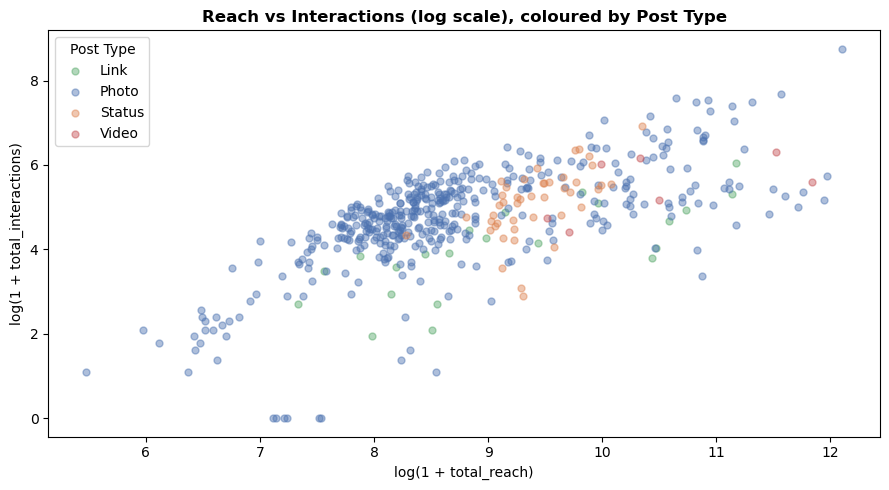

In [42]:
# Scatter plot: reach vs interactions (both log-scaled)
plt.figure(figsize=(9, 5))
type_colors_map = {'Photo':'#4C72B0','Status':'#DD8452','Link':'#55A868','Video':'#C44E52'}

for ptype, grp in df.groupby('post_type'):
    plt.scatter(
        np.log1p(grp['total_reach']),
        np.log1p(grp['total_interactions']),
        alpha=0.45, s=25, label=ptype, color=type_colors_map[ptype]
    )

plt.xlabel('log(1 + total_reach)')
plt.ylabel('log(1 + total_interactions)')
plt.title('Reach vs Interactions (log scale), coloured by Post Type', fontweight='bold')
plt.legend(title='Post Type')
plt.tight_layout()
plt.savefig('../docs/fig_09_reach_vs_interactions.png', dpi=120, bbox_inches='tight')
plt.show()

- **Reach is the strongest predictor.** More reach = more interactions. Makes complete sense — if more people see the post, more people can engage with it.

- **`engaged_users` and `fan_reach` have very high correlations.** This creates **multicollinearity** — when features are strongly correlated with each other, a plain linear regression model gets confused about which one is doing the work. Ridge regression handles this problem well.

- **`likes`, `comments`, and `shares` have r ≈ 1.0 with `total_interactions`** because they literally sum to it. Keeping them would be cheating — the model would just add them up. I'll drop them before modeling.

- **`paid` has a modest positive correlation.** Paid posts get more interactions, but mainly because they reach more people — not necessarily because the content is better.

- **Status posts outperform Photos in median interactions** even though Photos make up 85% of all posts.

---
### 15. Saving cleaned dataset

In [43]:
# Save the cleaned dataset for use in the next notebook
df.to_csv('../Data/cleaned_facebook.csv', index=False)